# Icescopy counts to INP per litre of air with INP-toolkit

Step-by-step analysis of the M1 base-rerun dataset, from freezing counts to INP concentrations per litre of air.

In [1]:
from dataclasses import asdict
from pathlib import Path
import csv
import hashlib
import json
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "inptk-matplotlib"))

# Use this checkout when launched from the project or its notebook folder.
# Otherwise use an installed inptk package.
project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/inptk").is_dir()),
    None,
)
if project_root is not None:
    sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import inptk

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.max_columns = 12
print(f"INP-toolkit {inptk.__version__}: {inptk.__file__}")


INP-toolkit 0.4.0: /Users/C832577250/Project/inptk/src/inptk/__init__.py


## 1. Choose the input and settings

Average exhausts each dilution before switching to the next. The first dilution
keeps its initial observations. Each dilution requires at least 3 liquid wells;
later dilutions also require at least 3 frozen wells. MLE uses the manual limits
below. Both use the same raw observations, blank assignments and 50 µL well volume.

Count selection uses a 0.5 °C grid before blank correction and calculation. The selected
skip-decreases policy omits lower Average points and keeps later points once
the concentration recovers. It does not terminate the curve at the first dip.


In [2]:
DATA_PATH = Path("/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun/freeze_count_timeseries.csv")
OLAF_REFERENCE_PATH = Path(
    "/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun/"
    "INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25 base rerun.csv"
)
RUN_ID = "M1-base-rerun"
SAMPLE_MAP = {f"Sample_{i}": "CRG_M1" for i in range(5)}
PLOT_SAMPLE_ID = "CRG_M1"
PLOT_CYCLE_ID = "0"
COMBINED_CURVE_ID = "CRG_M1"
CURVES = {COMBINED_CURVE_ID: {"inputs": list(SAMPLE_MAP), "cycle": PLOT_CYCLE_ID}}
FIT_STEP_C = 0.5  # MLE curve shape; analysis temperatures come from count selection.
TEMPERATURE_STEP_C = 0.5
TEMPERATURE_START_C = None  # Warmest input temperature; no rounding.
TEMPERATURE_END_C = None  # Coldest input temperature; no rounding.
TEMPERATURE_METHOD = "latest"
MLE_TEMPERATURE_RANGES_C = {
    "Sample_1": {"max_C": -10},
    "Sample_2": {"max_C": -15},
    "Sample_3": {"max_C": -20},
    "Sample_4": {"max_C": -25},
}
AVERAGE_MIN_FROZEN = 3
AVERAGE_MIN_UNFROZEN = 3
METHOD = "average"  # Or "mle"; each method uses its own limits.
DECREASE_POLICY = "skip_decreases"  # Skip dips and resume when concentration recovers.
TEMPERATURE_XLIM = (-30, -5)  # Temperature increases from left to right.

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Mount the data drive or update DATA_PATH: {DATA_PATH}")

GRID = dict(temperature_step_C=TEMPERATURE_STEP_C, temperature_start_C=TEMPERATURE_START_C,
            temperature_end_C=TEMPERATURE_END_C, temperature_method=TEMPERATURE_METHOD)


## 2. Read the raw Icescopy count export

Use every row with time, temperature and freezing counts, including rows without
an image ID. `Sample_5` is the assay blank. Each input has 32 wells of 50 µL.
The matching OLAF reference supplies air volume, suspension volume and filter
fraction; those metadata sources are recorded below.


In [3]:
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
reference_sha256 = hashlib.sha256(OLAF_REFERENCE_PATH.read_bytes()).hexdigest()
BLANK_INPUT = "Sample_5"
csv_header = {}
with DATA_PATH.open() as stream:
    for line in stream:
        if not line.startswith("#"):
            break
        row = next(csv.reader([line[1:].strip()]))
        if len(row) > 1:
            csv_header[row[0]] = row[1:]
blank_position = csv_header["sample_name"].index(BLANK_INPUT)
reference_metadata = {}
with OLAF_REFERENCE_PATH.open() as stream:
    for header_index, line in enumerate(stream):
        if line.strip().startswith("degC,"):
            break
        if "=" in line:
            key, value = line.split("=", 1)
            reference_metadata[key.strip()] = value.strip()
    else:
        raise ValueError("Reference CSV has no degC header")
assert reference_metadata["site"] == PLOT_SAMPLE_ID
reference = pd.read_csv(OLAF_REFERENCE_PATH, skiprows=header_index).rename(columns={
    "degC": "temperature_C", "INPS_L": "concentration",
    "lower_CI": "lower_error", "upper_CI": "upper_error",
})
air_metadata = {
    "air_volume_L": float(reference_metadata["vol_air_filt"]),
    "suspension_volume_mL": float(reference_metadata["vol_susp"]),
    "filter_fraction_used": float(reference_metadata["proportion_filter_used"]),
}
overrides = {name: dict(air_metadata) for name in list(SAMPLE_MAP)}
overrides[BLANK_INPUT] = {"sample_type": "other", "dilution": 1}
sample_map = {name: PLOT_SAMPLE_ID for name in list(SAMPLE_MAP)}
sample_map[BLANK_INPUT] = "water"
imported = inptk.read_icescopy(DATA_PATH, metadata=overrides, sample_map=sample_map, run_id=RUN_ID)
all_counts = imported.counts.to_dataframe()
observed_counts = all_counts.copy()
assert observed_counts.picture_id.nunique() == 482
assert len(observed_counts) == len(all_counts) == 8881 * 6
assert np.isfinite(observed_counts[["time_s", "temperature_C", "n_frozen", "n_total"]]).all().all()
assert observed_counts.n_total.eq(32).all()
assert observed_counts.groupby("measurement_id").n_frozen.diff().dropna().ge(0).all()
assert set(observed_counts.cycle_id) == {"0"}
assert all(m.droplet_volume_uL == 50 for m in imported.measurements.values())
assert [imported.measurements[name].dilution for name in list(SAMPLE_MAP)] == [1,13,169,2197,28561]
experiment = inptk.Experiment(
    counts=imported.counts,
    samples=imported.samples, measurements=imported.measurements,
    water_blank_map={name: [BLANK_INPUT] for name in list(SAMPLE_MAP)},
    source={"format": "icescopy", "path": str(DATA_PATH), "sha256": source_sha256,
            "air_metadata_source": str(OLAF_REFERENCE_PATH),
            "air_metadata_source_sha256": reference_sha256, "air_metadata": air_metadata,
            "blank_dilution_in_export": csv_header["dilution"][blank_position],
            "metadata_overrides": overrides},
)
display(pd.DataFrame([
    {"input": name, "role": "blank" if name == BLANK_INPUT else "sample",
     "wells": 32, "well_volume_uL": m.droplet_volume_uL,
     "sample_dilution": np.nan if name == BLANK_INPUT else m.dilution}
    for name, m in experiment.measurements.items()
]))
display(pd.DataFrame([dict(air_metadata, source=OLAF_REFERENCE_PATH.name)]))
print(f"Imported {len(all_counts):,} count rows; all rows are available for initial grid selection.")


,input,role,wells,well_volume_uL,sample_dilution
0,Sample_0,sample,32,50.0,1.0
1,Sample_1,sample,32,50.0,13.0
2,Sample_2,sample,32,50.0,169.0
3,Sample_3,sample,32,50.0,2197.0
4,Sample_4,sample,32,50.0,28561.0
5,Sample_5,blank,32,50.0,NaN


,air_volume_L,suspension_volume_mL,filter_fraction_used,source
0,17829.1,10.0,1.0,INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25...


Imported 53,286 count rows; all rows are available for initial grid selection.


In [4]:
raw_counts = experiment.counts.to_dataframe()
raw_counts["fraction_frozen"] = raw_counts.n_frozen / raw_counts.n_total
display(raw_counts.groupby(["sample_id", "run_id", "cycle_id", "measurement_id"],
                          sort=False).size().rename("observation_rows").to_frame())
plot_selection = dict(sample_id=PLOT_SAMPLE_ID, run_id=RUN_ID, cycle_id=PLOT_CYCLE_ID)
selected_counts = experiment.counts.select(**plot_selection).to_dataframe()
selected_counts["fraction_frozen"] = selected_counts.n_frozen / selected_counts.n_total


observation_rows
sample_id run_id        cycle_id measurement_id                  
CRG_M1    M1-base-rerun 0        Sample_0                    8881
                                 Sample_1                    8881
                                 Sample_2                    8881
                                 Sample_3                    8881
                                 Sample_4                    8881
water     M1-base-rerun 0        Sample_5                    8881

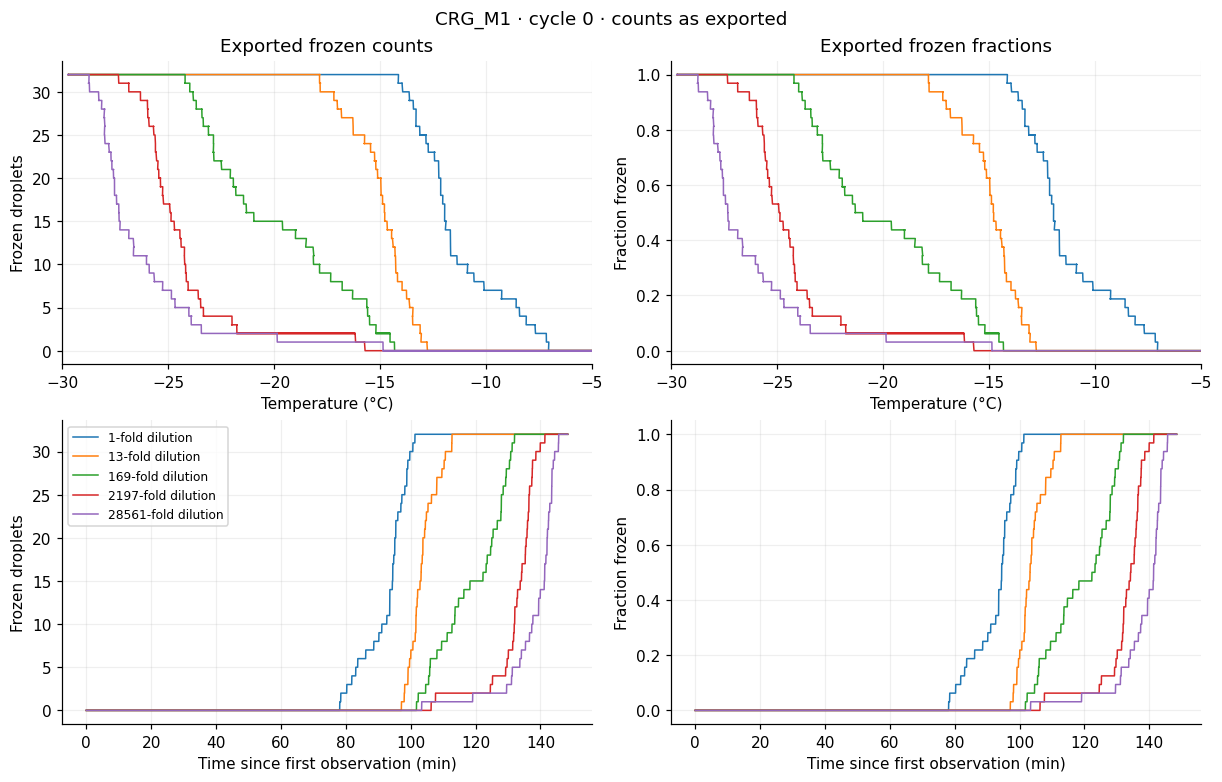

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout="constrained")
for measurement_id, frame in selected_counts.groupby("measurement_id", sort=False):
    dilution = experiment.measurements[measurement_id].dilution
    label = f"{dilution:g}-fold dilution"
    frame = frame.sort_values("time_s")
    axes[0, 0].plot(frame.temperature_C, frame.n_frozen, lw=1, label=label)
    axes[0, 1].plot(frame.temperature_C, frame.fraction_frozen, lw=1, label=label)
    axes[1, 0].plot(frame.time_s / 60, frame.n_frozen, lw=1, label=label)
    axes[1, 1].plot(frame.time_s / 60, frame.fraction_frozen, lw=1, label=label)
axes[0, 0].set(title="Exported frozen counts", xlabel="Temperature (°C)", ylabel="Frozen droplets", xlim=TEMPERATURE_XLIM)
axes[0, 1].set(title="Exported frozen fractions", xlabel="Temperature (°C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
axes[1, 0].set(xlabel="Time since first observation (min)", ylabel="Frozen droplets")
axes[1, 1].set(xlabel="Time since first observation (min)", ylabel="Fraction frozen")
for ax in axes.flat:
    ax.grid(alpha=0.2)
axes[1, 0].legend(fontsize=8, loc="upper left")
fig.suptitle(f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · counts as exported")
plt.show()


## 3. Calculate frozen fractions at the original observations

`frozen_fraction()` adds frozen count divided by total count. It preserves every
supplied observation and temperature, including repeated temperatures and small
warming steps. Repeated observations do not increase the number of droplets.


Original frozen-fraction observations: 53,286


,sample_id,cycle_id,measurement_id,temperature_C,n_total,n_frozen,fraction_frozen
0,CRG_M1,0,Sample_0,20.634,32.0,0.0,0.0
1,CRG_M1,0,Sample_0,20.632,32.0,0.0,0.0
2,CRG_M1,0,Sample_0,20.634,32.0,0.0,0.0
3,CRG_M1,0,Sample_0,20.615,32.0,0.0,0.0
4,CRG_M1,0,Sample_0,20.610,32.0,0.0,0.0


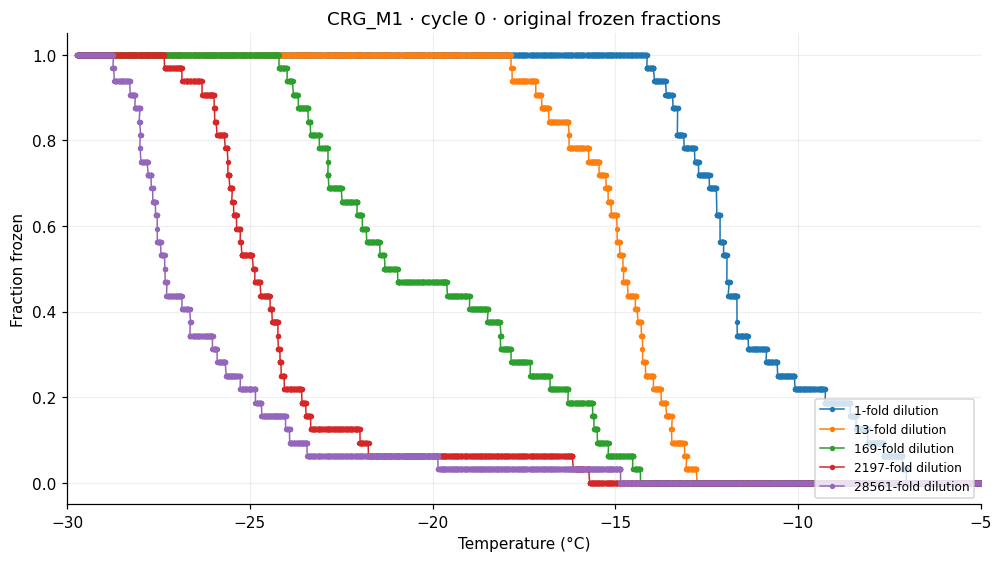

In [6]:
fractions = inptk.frozen_fraction(experiment)
fraction_df = fractions.to_dataframe()
print(f"Original frozen-fraction observations: {len(fraction_df):,}")
display(fraction_df[["sample_id", "cycle_id", "measurement_id", "temperature_C", "n_total", "n_frozen", "fraction_frozen"]].head())

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for measurement_id, frame in fractions.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False):
    frame = frame.sort_values("time_s", kind="stable")
    dilution = experiment.measurements[measurement_id].dilution
    ax.plot(frame.temperature_C, frame.fraction_frozen, "o-", ms=2.5, lw=1, label=f"{dilution:g}-fold dilution")
ax.set(title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · original frozen fractions", xlabel="Temperature (°C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.2)
plt.show()


### Applied temperature limits

Average uses the package's suggested limits: exhaust the least-diluted input,
then move to the next dilution. A later dilution does not contribute while the
previous one remains usable. Initial observations of the first dilution are
retained automatically. Blank flags do not remove points. Zero concentrations
remain in the tables but cannot be drawn on the logarithmic concentration axis.


In [7]:
auto_suggestions = inptk.suggest_temperature_ranges(
    experiment, curves=CURVES,
    min_frozen=AVERAGE_MIN_FROZEN, min_unfrozen=AVERAGE_MIN_UNFROZEN,
)
RANGES_BY_METHOD = {
    "mle": MLE_TEMPERATURE_RANGES_C,
    "average": auto_suggestions.temperature_ranges_C,
}
display(pd.DataFrame.from_dict(auto_suggestions.inputs, orient="index"))
auto_report = auto_suggestions.observations.to_dataframe()
display(auto_report.groupby(["measurement_id", "blank_status"]).size().rename("observations"))


,run_id,cycle_id,range_C,dilution,min_frozen_applied,status,kept_observations,excluded_observations,warm_limit_reason,cold_limit_reason
Sample_0,M1-base-rerun,0,"{'min_C': -13.621, 'max_C': 20.655}",1.0,False,suggested,5963,2918,[observed_temperature_limit],[too_few_liquid]
Sample_1,M1-base-rerun,0,"{'min_C': -17.164, 'max_C': -13.622}",13.0,True,suggested,657,8224,[previous_dilution_active],[too_few_liquid]
Sample_2,M1-base-rerun,0,"{'min_C': -23.808, 'max_C': -17.166}",169.0,True,suggested,1208,7673,[previous_dilution_active],[too_few_liquid]
Sample_3,M1-base-rerun,0,"{'min_C': -26.308, 'max_C': -23.817}",2197.0,True,suggested,466,8415,[previous_dilution_active],[too_few_liquid]
Sample_4,M1-base-rerun,0,"{'min_C': -28.285, 'max_C': -26.31}",28561.0,True,suggested,346,8535,[previous_dilution_active],[too_few_liquid]


measurement_id  blank_status                
Sample_0        distinguished_from_blank        1165
                not_assessed_outside_range      2918
                not_distinguished_from_blank    4798
Sample_1        distinguished_from_blank         657
                not_assessed_outside_range      8224
Sample_2        distinguished_from_blank        1208
                not_assessed_outside_range      7673
Sample_3        distinguished_from_blank         466
                not_assessed_outside_range      8415
Sample_4        distinguished_from_blank           6
                not_assessed_outside_range      8535
                not_distinguished_from_blank     340
Name: observations, dtype: int64

## 4. Calculate each input separately

Use the selected `METHOD` and its temperature limits. Average estimates each
selected temperature separately; MLE fits each input's selected freezing history. Both include
the assigned raw blank. Convert suspension concentration to INP per litre of air.


In [8]:
individual_suspension = inptk.cumulative_spectrum(
    fractions, experiment=experiment, method=METHOD, fit_step_C=FIT_STEP_C if METHOD == "mle" else None,
    **GRID,
    temperature_ranges_C=RANGES_BY_METHOD[METHOD],
)
individual_air = inptk.convert_concentration(
    individual_suspension, experiment.samples, basis="sampled_air",
)
sample = experiment.samples[PLOT_SAMPLE_ID]
print("Sample metadata:", asdict(sample))
print(f"Suspension-to-air multiplier: {sample.factor_for('sampled_air'):.10g}")
display(individual_air.select(**plot_selection).to_dataframe()[[
    "measurement_id", "temperature_C", "concentration", "lower_error", "upper_error", "unit",
]].head())


Sample metadata: {'sample_id': 'CRG_M1', 'sample_name': '', 'sample_type': 'air', 'air_volume_L': 17829.1, 'suspension_volume_mL': 10.0, 'filter_fraction_used': 1.0, 'dry_mass_g': None}
Suspension-to-air multiplier: 0.0005608808072


,measurement_id,temperature_C,concentration,lower_error,upper_error,unit
0,Sample_0,20.655,0.0,0.0,0.000673,INP_per_L_air
1,Sample_0,20.155,0.0,0.0,0.000673,INP_per_L_air
2,Sample_0,19.655,0.0,0.0,0.000673,INP_per_L_air
3,Sample_0,19.155,0.0,0.0,0.000673,INP_per_L_air
4,Sample_0,18.655,0.0,0.0,0.000673,INP_per_L_air


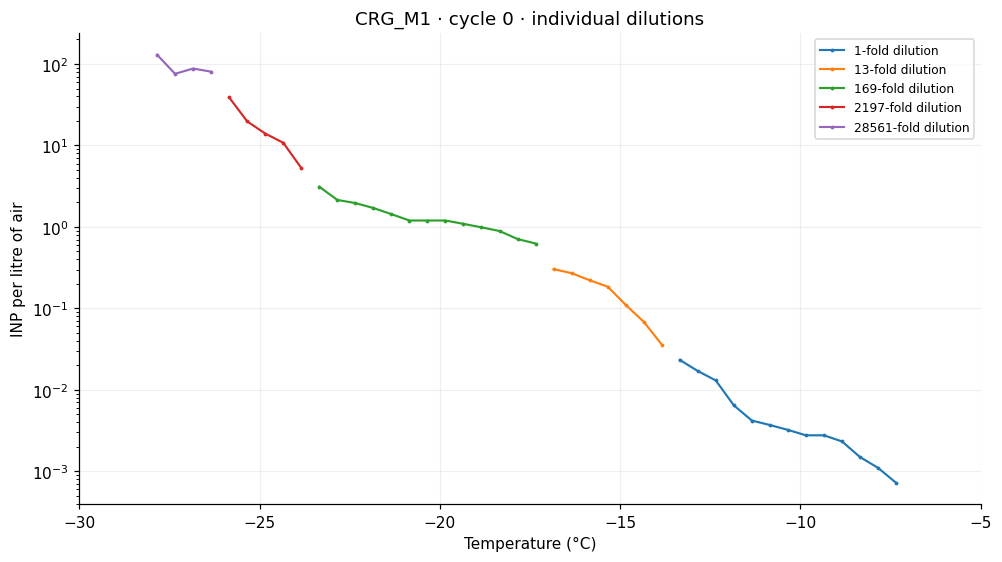

Log plots omit zero, negative and infinite concentrations; tables retain them.


In [9]:
def draw_spectrum(ax, frame, *, label, color, show_errors=False, linestyle="-", alpha=1):
    """Plot one selected curve; retain gaps where a log plot cannot show a value."""
    if "point_order" in frame:
        frame = frame.sort_values("point_order", kind="stable")
    elif "time_s" in frame:
        frame = frame.sort_values("time_s", kind="stable")
    # A new segment starts after an excluded observation; never connect across it.
    if "segment_id" in frame and frame.segment_id.nunique() > 1:
        for index, (_, segment) in enumerate(frame.groupby("segment_id", sort=False)):
            draw_spectrum(ax, segment, label=label if index == 0 else None,
                          color=color, show_errors=show_errors,
                          linestyle=linestyle, alpha=alpha)
        return
    visible = np.isfinite(frame.concentration) & (frame.concentration > 0)
    values = frame.concentration.where(visible)
    ax.plot(frame.temperature_C, values, color=color, linestyle=linestyle,
            marker=".", ms=3, lw=1.4, alpha=alpha, label=label)
    if show_errors:
        lower = frame.concentration - frame.lower_error
        upper = frame.concentration + frame.upper_error
        valid_band = visible & (lower > 0) & np.isfinite(lower) & np.isfinite(upper)
        ax.fill_between(frame.temperature_C, lower.where(valid_band), upper.where(valid_band),
                        color=color, alpha=0.13)


fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for index, (measurement_id, frame) in enumerate(individual_air.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False)):
    dilution = experiment.measurements[measurement_id].dilution
    draw_spectrum(ax, frame, label=f"{dilution:g}-fold dilution", color=f"C{index}")
ax.set(yscale="log", title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · individual dilutions",
       xlabel="Temperature (°C)", ylabel="INP per litre of air", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.show()
print("Log plots omit zero, negative and infinite concentrations; tables retain them.")


## 5. Calculate the combined curve on the analysis grid

MLE fits one monotone sample curve and one blank curve to all selected freezing
histories. Each physical well contributes once. Temperature ranges select which
observations enter the fit; later data can also affect earlier estimates.

Average estimates concentration separately at each temperature and then takes an
equal-weight mean. Its curve can decrease when the contributors or blank change.
Automatic Average limits use one dilution at a time, switching after its cold
limit. Manual overlapping ranges would average the contributing inputs.
MLE uses the manual limits.
The selected decrease policy still applies to Average.

Shading shows nominal approximate 95% pointwise intervals. MLE refits the whole
curve and blank for each bound; the shaded area is not a simultaneous 95% band.
Counts are selected onto the 0.5 °C grid first. Plot the calculated values directly.

In [10]:
range_controls = pd.DataFrame([
    {
        "method": method,
        "measurement_id": name,
        "dilution": metadata.dilution,
        "min_C": RANGES_BY_METHOD[method].get(name, {}).get("min_C"),
        "max_C": RANGES_BY_METHOD[method].get(name, {}).get("max_C"),
    }
    for method in ("mle", "average")
    for name, metadata in experiment.measurements.items() if name in SAMPLE_MAP
])
display(range_controls)

combined_suspension = {
    method: inptk.estimate_concentration(
        fractions, experiment=experiment, method=method, curves=CURVES,
    **GRID,
        fit_step_C=FIT_STEP_C if method == "mle" else None,
        temperature_ranges_C=RANGES_BY_METHOD[method],
    )
    for method in ("mle", "average")
}
combined_air_candidates = {
    method: inptk.convert_concentration(table, experiment.samples, basis="sampled_air")
    for method, table in combined_suspension.items()
}
combined_air = {
    method: inptk.finalize_spectrum(table, decrease_policy=DECREASE_POLICY)
    for method, table in combined_air_candidates.items()
}

combined_selection = {"curve_id": COMBINED_CURVE_ID}
print("Named concentration curve:", COMBINED_CURVE_ID)

for method, table in combined_air.items():
    print(f"{method}: {len(table):,} retained points; warnings: {table.warnings or 'none'}")
    report = next(item for item in table.history[-1]["groups"]
                  if item["curve_id"] == combined_selection["curve_id"])
    first_decrease = next((item for item in report["excluded"] if item["reason"] == "decrease"), None)
    if first_decrease is not None:
        print(f"First decrease at {first_decrease['temperature_C']:.4g} °C: "
              f"{first_decrease['reference_concentration']:.6g} → "
              f"{first_decrease['concentration']:.6g} INP/L. Policy: {DECREASE_POLICY}.")
    selected = combined_air[method].select(**combined_selection).to_dataframe()
    display(selected.tail(5)[[
        "temperature_C", "concentration", "lower_error", "upper_error", "unit",
    ]])
# The least-diluted input contributes from its first original observation.
average_candidates = combined_air_candidates["average"].to_dataframe()
assert average_candidates.temperature_C.iloc[0] == selected_counts.loc[
    selected_counts.measurement_id.eq("Sample_0"), "temperature_C"
].max()
assert "Sample_0" in json.loads(average_candidates.contributing_measurement_ids.iloc[0])
average_retained = combined_air["average"].to_dataframe()
print(f"Average retained range: {average_retained.temperature_C.max():.3f} to "
      f"{average_retained.temperature_C.min():.3f} °C.")


,method,measurement_id,dilution,min_C,max_C
0,mle,Sample_0,1.0,NaN,NaN
1,mle,Sample_1,13.0,NaN,-10.000
2,mle,Sample_2,169.0,NaN,-15.000
3,mle,Sample_3,2197.0,NaN,-20.000
4,mle,Sample_4,28561.0,NaN,-25.000
5,average,Sample_0,1.0,-13.621,20.655
6,average,Sample_1,13.0,-17.164,-13.622
7,average,Sample_2,169.0,-23.808,-17.166
8,average,Sample_3,2197.0,-26.308,-23.817
9,average,Sample_4,28561.0,-28.285,-26.310


Named concentration curve: CRG_M1
mle: 99 retained points; warnings: ["{'sample_id': 'CRG_M1', 'curve_id': 'CRG_M1'}: final selection excluded 3 of 102 points using skip_decreases"]


,temperature_C,concentration,lower_error,upper_error,unit
94,-26.345,56.813917,21.472164,30.112941,INP_per_L_air
95,-26.845,61.777140,25.532652,38.817890,INP_per_L_air
96,-27.345,100.161634,50.233083,95.845471,INP_per_L_air
97,-27.845,154.330961,100.272015,225.911050,INP_per_L_air
98,-28.345,317.992612,260.098787,594.307190,INP_per_L_air


average: 97 retained points; warnings: ["Curve 'CRG_M1': 4 points have no eligible input", "{'sample_id': 'CRG_M1', 'curve_id': 'CRG_M1'}: final selection excluded 5 of 102 points using skip_decreases"]
First decrease at -27.34 °C: 87.9258 → 75.7357 INP/L. Policy: skip_decreases.


,temperature_C,concentration,lower_error,upper_error,unit
92,-25.345,19.773911,9.387784,12.374587,INP_per_L_air
93,-25.845,38.829255,15.310180,21.399186,INP_per_L_air
94,-26.345,80.517709,80.517709,105.281557,INP_per_L_air
95,-26.845,87.925815,87.925815,120.706367,INP_per_L_air
96,-27.845,129.905480,129.905480,259.299554,INP_per_L_air


Average retained range: 20.655 to -27.845 °C.


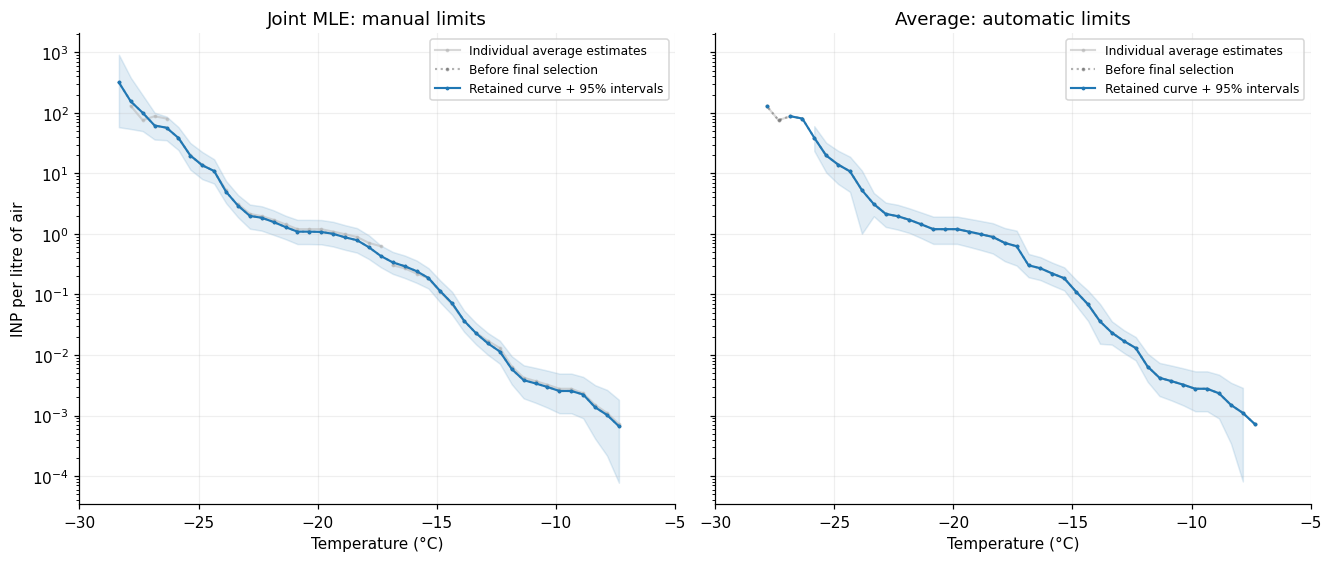

Intervals reaching zero cannot be shaded on the log axis. Saturated tails have no finite fit.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True,
                         layout="constrained")
for ax, method in zip(axes, ("mle", "average")):
    for index, (measurement_id, frame) in enumerate(
        individual_air.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False)
    ):
        draw_spectrum(ax, frame, label=f"Individual {METHOD} estimates" if index == 0 else None,
                      color="0.7", alpha=0.5)
    draw_spectrum(ax, combined_air_candidates[method].select(**combined_selection).to_dataframe(),
                  label="Before final selection", color="0.4", linestyle=":", alpha=0.5)
    draw_spectrum(ax, combined_air[method].select(**combined_selection).to_dataframe(),
                  label="Retained curve + 95% intervals", color="C0", show_errors=True)
    ax.set(yscale="log", title="Joint MLE: manual limits" if method == "mle" else "Average: automatic limits",
           xlabel="Temperature (°C)", xlim=TEMPERATURE_XLIM)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
axes[0].set_ylabel("INP per litre of air")
plt.show()
print("Intervals reaching zero cannot be shaded on the log axis. Saturated tails have no finite fit.")


## 6. Compare with the supplied OLAF final table

Show final concentrations at the selected analysis temperatures. Excluded points
remain available in the candidate tables.


,site,start_time,end_time,filter_color,sample_type,vol_air_filt,proportion_filter_used,vol_susp,treatment,notes,user,IS
0,CRG_M1,2025-08-12 13:00:00,2025-08-13 13:00:00,white,air,17829.1,1.0,10,base,none,Carson,IS1a


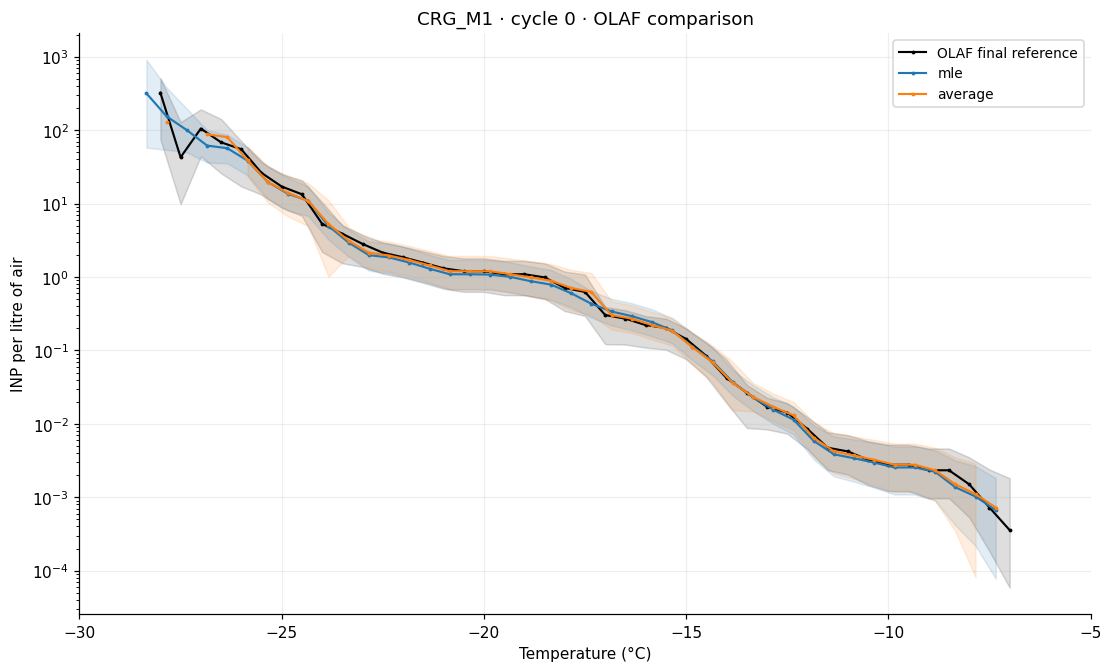

In [12]:
if OLAF_REFERENCE_PATH.is_file():
    reference_metadata = {}
    with OLAF_REFERENCE_PATH.open(encoding="utf-8") as stream:
        for header_index, line in enumerate(stream):
            if line.strip().startswith("degC,"):
                break
            if "=" in line:
                key, value = line.split("=", 1)
                reference_metadata[key.strip()] = value.strip()
        else:
            raise ValueError("OLAF reference is missing its degC header")
    reference = pd.read_csv(OLAF_REFERENCE_PATH, skiprows=header_index).rename(columns={
        "degC": "temperature_C", "INPS_L": "concentration",
        "lower_CI": "lower_error", "upper_CI": "upper_error",
    })
    for column in ("temperature_C", "concentration", "lower_error", "upper_error"):
        reference[column] = pd.to_numeric(reference[column], errors="raise")
    display(pd.DataFrame([reference_metadata]))
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    draw_spectrum(ax, reference, label="OLAF final reference", color="black", show_errors=True)
    for index, (label, table) in enumerate(combined_air.items()):
        draw_spectrum(ax, table.select(**combined_selection).to_dataframe(),
                      label=label, color=f"C{index}", show_errors=True)
    ax.set(yscale="log", title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · OLAF comparison",
           xlabel="Temperature (°C)", ylabel="INP per litre of air", xlim=TEMPERATURE_XLIM)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.show()
else:
    print(f"Optional reference is unavailable: {OLAF_REFERENCE_PATH}")


## 6. Verify the public 0.5 °C fit

All supplied rows are available for count selection. MLE uses the selected sample
and blank counts at the analysis temperatures. Concentration and uncertainty are
reported at those same temperatures. Blank assignment is explicit.


In [13]:
fit_history = combined_suspension["mle"].history[-1]
fit_details = fit_history["joint_curve_fits"][COMBINED_CURVE_ID]
assert fit_history["fit_step_C"] == FIT_STEP_C == 0.5
assert fit_details["physical_droplets"] == 192
pd.testing.assert_frame_equal(experiment.counts.to_dataframe(), imported.counts.to_dataframe())
original_grid = combined_air["mle"].to_dataframe()
assert original_grid.temperature_C.is_monotonic_decreasing
display(original_grid[["temperature_C", "concentration", "lower_error", "upper_error"]].iloc[::20])
print("Public MLE fit: 0.5 °C; all supplied time-temperature-count rows preserved.")


,temperature_C,concentration,lower_error,upper_error
0,20.655,0.000000,0.000000,0.000625
20,10.655,0.000000,0.000000,0.000625
40,0.655,0.000000,0.000000,0.000625
60,-9.345,0.002544,0.001453,0.002385
80,-19.345,1.003442,0.383605,0.580756


Public MLE fit: 0.5 °C; all supplied time-temperature-count rows preserved.


## 7. Named individual and combined curves

Request the main curve and each individual input through the same interface.
The original counts and observed fractions remain available separately.


In [14]:
output_curves = {
    **CURVES,
    **{name: {"inputs": [name], "cycle": PLOT_CYCLE_ID} for name in SAMPLE_MAP},
}
result = inptk.analyze_concentration(
    experiment, method=METHOD, curves=output_curves,
    **GRID,
    fit_step_C=FIT_STEP_C if METHOD == "mle" else None,
    temperature_ranges_C=RANGES_BY_METHOD[METHOD],
    output_basis="sampled_air", decrease_policy=DECREASE_POLICY,
)
curve = result.curves[COMBINED_CURVE_ID]
pd.testing.assert_frame_equal(result.counts.to_dataframe(), experiment.counts.to_dataframe())
pd.testing.assert_frame_equal(result.frozen_fraction.to_dataframe(), fractions.to_dataframe())
pd.testing.assert_frame_equal(
    curve.cumulative.to_dataframe(), combined_air[METHOD].select(**combined_selection).to_dataframe(),
)

assert list(result.curves) == list(output_curves)
for named_curve in result.curves.values():
    for source in named_curve.sources:
        selected = experiment.counts.select(
            measurement_id=source["measurement_id"], run_id=source["run_id"],
            cycle_id=source["cycle_id"],
        )
        assert len(selected)
display(pd.DataFrame([
    {"curve_id": name, "kind": value.kind, "inputs": len(value.sources),
     "retained_points": len(value.cumulative), "excluded_points": len(value.excluded)}
    for name, value in result.curves.items()
]))
display(result.curves["Sample_0"].cumulative.to_dataframe().head())
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_sha256
assert hashlib.sha256(OLAF_REFERENCE_PATH.read_bytes()).hexdigest() == reference_sha256
print("Verified: named curves match separate steps; original count CSV and reference preserved.")


,curve_id,kind,inputs,retained_points,excluded_points
0,CRG_M1,combined,5,97,5
1,Sample_0,individual,1,69,33
2,Sample_1,individual,1,7,95
3,Sample_2,individual,1,13,89
4,Sample_3,individual,1,5,97
5,Sample_4,individual,1,3,99


,sample_id,curve_id,point_id,point_order,temperature_C,alignment,...,correction_state,at_zero_boundary,is_extrapolated,used_in_final,final_selection_status,segment_id
0,CRG_M1,Sample_0,point:0,0,20.655,latest,...,water_blank_corrected,True,False,True,kept,0
1,CRG_M1,Sample_0,point:1,1,20.155,latest,...,water_blank_corrected,True,False,True,kept,0
2,CRG_M1,Sample_0,point:2,2,19.655,latest,...,water_blank_corrected,True,False,True,kept,0
3,CRG_M1,Sample_0,point:3,3,19.155,latest,...,water_blank_corrected,True,False,True,kept,0
4,CRG_M1,Sample_0,point:4,4,18.655,latest,...,water_blank_corrected,True,False,True,kept,0


Verified: named curves match separate steps; original count CSV and reference preserved.


## 8. Optional export

External export is off by default. To save, set `SAVE_RESULTS=True` and choose a
new folder. Exports include the applied limits and the automatic suggestion report.
Original project and CSV files remain unchanged.


In [15]:
SAVE_RESULTS = False
OUTPUT_DIR = DATA_PATH.parent / "inptk_m1_results"

if SAVE_RESULTS:
    OUTPUT_DIR.mkdir(exist_ok=False)
    result.save(OUTPUT_DIR / f"{METHOD}.inptk")
    result.export_csv(OUTPUT_DIR / "concentration_air.csv", curve_id=COMBINED_CURVE_ID)
    fraction_df.to_csv(OUTPUT_DIR / "frozen_fractions.csv", index=False)
    individual_air.to_dataframe().to_csv(OUTPUT_DIR / "individual_dilutions_air.csv", index=False)
    pd.concat(
        [table.to_dataframe().assign(method=label) for label, table in combined_air.items()],
        ignore_index=True,
    ).to_csv(OUTPUT_DIR / "combined_methods_air.csv", index=False)
    auto_suggestions.observations.to_dataframe().to_csv(
        OUTPUT_DIR / "average_range_diagnostics.csv", index=False,
    )
    (OUTPUT_DIR / "average_range_suggestions.json").write_text(
        json.dumps(auto_suggestions.settings, indent=2) + "\n"
    )
    (OUTPUT_DIR / "applied_temperature_ranges.json").write_text(
        json.dumps(RANGES_BY_METHOD, indent=2) + "\n"
    )
    (OUTPUT_DIR / "method_history.json").write_text(
        json.dumps({label: table.history for label, table in combined_air.items()}, indent=2) + "\n"
    )
    print(f"Saved analysis and tables to {OUTPUT_DIR}")
else:
    print("External export is off. Set SAVE_RESULTS=True and choose a new folder when ready.")


External export is off. Set SAVE_RESULTS=True and choose a new folder when ready.
